In [65]:
from IPython.display import clear_output
from Chandelier_ZLSMA_Filter_Future import *
from Support_Resistance_Future_Scaner import *
from Display_Future import *
from Buy_Sell_Presure_Scaner import *

In [82]:
def trade_chandelier_zlsma(symbol="BTCUSDT", timeframe='15m', zlsma_length=200, zlsma_limit=400, momentum_limit=100, max_signal_candles=3, use_support_resistance_filter=False):
    # Get chandelier data for the specified symbol
    btc_out = only_chandelier(symbol)
    btc_out = btc_out[198:]  # Slice the dataframe as per original logic
    
    # Initialize scanner
    scanner = Binance_Support_Resistance_Perpetual_Scanner()
    
    # Determine trade direction based on signals
    if btc_out['buy_signal'].sum() == 2:
        trade_type = 'LONG'
    elif btc_out['sell_signal'].sum() == 2:
        trade_type = 'SHORT'
    else:
        return pd.DataFrame()  # Return empty dataframe if no valid signals
    
    # Get active symbols
    active_symbols = scanner.get_active_symbols()
    
    # Scan for signals
    results = scan_perpetual_simple(
        symbols=active_symbols,
        timeframe=timeframe,
        zlsma_length=zlsma_length,
        zlsma_limit=zlsma_limit,
        momentum_limit=momentum_limit,
        max_signal_candles=max_signal_candles,
        trade_type='both'
    )
    
    # Filter results
    results = results[['symbol', 'current_price', 'current_signal', 'signal_candles_count', 'trade_type']]
    
    # Process based on trade type
    if trade_type == 'LONG':
        filtered_results = results[results['trade_type'] == 'LONG']
        filtered_results = filtered_results[filtered_results['current_price'] <= 30]
        buy_sell_pressure = get_binance_buy_sell_pressure(filtered_results['symbol'].tolist(), apply_filters=False, top_n=50)
        
        # Rescan filtered symbols
        final_results = scan_perpetual_simple(
            symbols=filtered_results['symbol'].tolist(),
            timeframe=timeframe,
            zlsma_length=zlsma_length,
            zlsma_limit=zlsma_limit,
            momentum_limit=momentum_limit,
            max_signal_candles=max_signal_candles,
            trade_type='both'
        )
        
        if use_support_resistance_filter:
            # Get support/resistance data
            sup_reg_results = scanner.scan_multiple_coins(final_results['symbol'].tolist())
            sup_reg_results = pd.DataFrame(sup_reg_results)
            sup_reg_results = sup_reg_results[sup_reg_results['near_support'] == True]
            sup_reg_results = sup_reg_results[sup_reg_results['near_resistance'] == False]
            return sup_reg_results
        else:
            return final_results
        
    elif trade_type == 'SHORT':
        filtered_results = results[results['trade_type'] == 'SHORT']
        filtered_results = filtered_results[filtered_results['current_price'] <= 30]
        buy_sell_pressure = get_binance_buy_sell_pressure(filtered_results['symbol'].tolist(), apply_filters=False, top_n=50)
        
        # Rescan filtered symbols
        final_results = scan_perpetual_simple(
            symbols=sell_pressure['symbol'].tolist(),
            timeframe=timeframe,
            zlsma_length=zlsma_length,
            zlsma_limit=zlsma_limit,
            momentum_limit=momentum_limit,
            max_signal_candles=max_signal_candles,
            trade_type='both'
        )
        
        if use_support_resistance_filter:
            # Get support/resistance data
            sup_reg_results = scanner.scan_multiple_coins(final_results['symbol'].tolist())
            sup_reg_results = pd.DataFrame(sup_reg_results)
            sup_reg_results = sup_reg_results[sup_reg_results['near_resistance'] == True]
            sup_reg_results = sup_reg_results[sup_reg_results['near_support'] == False]
            return sup_reg_results
        else:
            return final_results
    
    return pd.DataFrame()  # Return empty dataframe if no conditions met

In [85]:
out_result = trade_chandelier_zlsma(use_support_resistance_filter=False)

Fetching BTCUSDT/USDT data from Binance...

🔍 Scanning for LONG opportunities...
⚡ Step 1: Scanning 444 coins with Simple Momentum...
✅ 1000000BOBUSDT passed Momentum filter
✅ ACHUSDT passed Momentum filter
✅ ARKUSDT passed Momentum filter
✅ ASRUSDT passed Momentum filter
✅ AWEUSDT passed Momentum filter
✅ BANANAUSDT passed Momentum filter
✅ BELUSDT passed Momentum filter
✅ BNBUSDT passed Momentum filter
✅ BROCCOLIF3BUSDT passed Momentum filter
✅ DEXEUSDT passed Momentum filter
✅ DIAUSDT passed Momentum filter
✅ DUSKUSDT passed Momentum filter
✅ ETCUSDT passed Momentum filter
✅ FLMUSDT passed Momentum filter
✅ GLMUSDT passed Momentum filter
✅ LPTUSDT passed Momentum filter
✅ OGUSDT passed Momentum filter
✅ PENGUUSDT passed Momentum filter
✅ QUICKUSDT passed Momentum filter
✅ SOONUSDT passed Momentum filter
✅ SXPUSDT passed Momentum filter
✅ USDCUSDT passed Momentum filter
✅ XRPUSDT passed Momentum filter
📊 23 coins passed Momentum filter
📈 Step 2: Applying ZLSMA filter to 23 coins...
🎯

In [86]:
out_result

,symbol,current_price,current_signal,signal_candles_count,signal_start_time,current_time,prev_opposite_time,prev_opposite_price,momentum,sma_fast,sma_slow,market_type,trade_type,contract_type,zlsma_200,price_distance_zlsma
0,ASRUSDT,2.190000,BUY,1,2025-07-07 09:00:00,2025-07-07 09:00:00,2025-07-06 23:45:00,2.113000,0.020979,2.167000,2.153900,PERPETUAL,LONG,PERPETUAL,2.168274,0.028726
1,QUICKUSDT,0.019400,BUY,1,2025-07-07 09:00:00,2025-07-07 09:00:00,2025-07-07 06:30:00,0.019080,0.016771,0.019386,0.019250,PERPETUAL,LONG,PERPETUAL,0.018559,0.000841
2,BROCCOLIF3BUSDT,0.009329,BUY,1,2025-07-07 09:00:00,2025-07-07 09:00:00,2025-07-07 07:45:00,0.009227,0.009195,0.009303,0.009295,PERPETUAL,LONG,PERPETUAL,0.009083,0.000246
3,USDCUSDT,0.999330,BUY,1,2025-07-07 09:00:00,2025-07-07 09:00:00,2025-07-06 23:15:00,0.998853,0.000340,0.999330,0.999259,PERPETUAL,LONG,PERPETUAL,0.999127,0.000203
4,DEXEUSDT,7.669000,BUY,2,2025-07-07 08:45:00,2025-07-07 09:00:00,2025-07-07 00:45:00,7.542000,0.001829,7.663600,7.641400,PERPETUAL,LONG,PERPETUAL,7.620603,0.048397
5,1000000BOBUSDT,0.066690,BUY,2,2025-07-07 08:45:00,2025-07-07 09:00:00,2025-07-07 07:30:00,0.066010,0.004519,0.066522,0.066391,PERPETUAL,LONG,PERPETUAL,0.063960,0.002790
6,BELUSDT,0.238900,BUY,2,2025-07-07 08:45:00,2025-07-07 09:00:00,2025-07-07 07:15:00,0.235500,0.015300,0.237840,0.237400,PERPETUAL,LONG,PERPETUAL,0.237570,0.001330
7,LPTUSDT,6.250000,BUY,3,2025-07-07 08:30:00,2025-07-07 09:00:00,2025-07-07 08:15:00,6.189000,0.012802,6.219600,6.206950,PERPETUAL,LONG,PERPETUAL,6.109990,0.140010
8,DUSKUSDT,0.052270,BUY,3,2025-07-07 08:30:00,2025-07-07 09:00:00,2025-07-07 06:45:00,0.050310,0.038958,0.052192,0.051104,PERPETUAL,LONG,PERPETUAL,0.051048,0.001192


In [2]:
scanner = Binance_Support_Resistance_Perpetual_Scanner()
active_symbols = scanner.get_active_symbols()

In [46]:
results_Chandlier_zlsm = scan_perpetual_simple(
    symbols=active_symbols,
    timeframe='15m',
    zlsma_length=200,  # Reduced from 200
    zlsma_limit=400,   # Reduced from 500
    momentum_limit=100, # Reduced from 200
    max_signal_candles=3,
    trade_type='both'  # 'long', 'short', or 'both'
)


🔍 Scanning for LONG opportunities...
⚡ Step 1: Scanning 444 coins with Simple Momentum...
✅ 1000RATSUSDT passed Momentum filter
✅ AGTUSDT passed Momentum filter
✅ ALPINEUSDT passed Momentum filter
✅ ARBUSDT passed Momentum filter
✅ ARPAUSDT passed Momentum filter
✅ AVAUSDT passed Momentum filter
✅ BAKEUSDT passed Momentum filter
✅ BANUSDT passed Momentum filter
✅ CAKEUSDT passed Momentum filter
✅ CELOUSDT passed Momentum filter
✅ CKBUSDT passed Momentum filter
✅ CRVUSDT passed Momentum filter
✅ CTKUSDT passed Momentum filter
✅ DEXEUSDT passed Momentum filter
✅ DODOXUSDT passed Momentum filter
✅ DUSDT passed Momentum filter
✅ DUSKUSDT passed Momentum filter
✅ EDUUSDT passed Momentum filter
✅ ETHFIUSDT passed Momentum filter
✅ FARTCOINUSDT passed Momentum filter
✅ FLMUSDT passed Momentum filter
✅ FORMUSDT passed Momentum filter
✅ GASUSDT passed Momentum filter
✅ GHSTUSDT passed Momentum filter
✅ GLMUSDT passed Momentum filter
✅ GMXUSDT passed Momentum filter
✅ GTCUSDT passed Momentum fi

In [47]:
results_Chandlier_zlsm = results_Chandlier_zlsm[['symbol', 'current_price', 'current_signal', 'signal_candles_count', 
                                                'trade_type']]


In [48]:
LONG_Chandlier_zlsm = results_Chandlier_zlsm[results_Chandlier_zlsm['trade_type'] == 'LONG']
LONG_Chandlier_zlsm = LONG_Chandlier_zlsm[LONG_Chandlier_zlsm['current_price'] <= 30]
LONG_Chandlier_zlsm

,symbol,current_price,current_signal,signal_candles_count,trade_type
17,FORMUSDT,2.754000,BUY,1,LONG
18,GASUSDT,2.892000,BUY,1,LONG
10,DEXEUSDT,7.656000,BUY,1,LONG
34,SPXUSDT,1.368900,BUY,1,LONG
15,FARTCOINUSDT,1.182600,BUY,1,LONG
1,ALPINEUSDT,0.697200,BUY,1,LONG
24,JTOUSDT,1.928100,BUY,1,LONG
27,NMRUSDT,7.515000,BUY,1,LONG
31,SEIUSDT,0.266800,BUY,1,LONG
2,ARBUSDT,0.336900,BUY,1,LONG


In [49]:
SHORT_Chandlier_zlsm = results_Chandlier_zlsm[results_Chandlier_zlsm['trade_type'] == 'SHORT']
SHORT_Chandlier_zlsm = SHORT_Chandlier_zlsm[SHORT_Chandlier_zlsm['current_price'] <= 30]
SHORT_Chandlier_zlsm

,symbol,current_price,current_signal,signal_candles_count,trade_type
41,BMTUSDT,0.087760,SELL,1,SHORT
42,BUSDT,0.393820,SELL,2,SHORT
47,UXLINKUSDT,0.372300,SELL,2,SHORT
43,DIAUSDT,0.372100,SELL,2,SHORT
44,GUNUSDT,0.038030,SELL,2,SHORT
45,JSTUSDT,0.034575,SELL,2,SHORT
40,BANKUSDT,0.067718,SELL,3,SHORT


In [ ]:
buy_buy_pressure = get_binance_buy_sell_pressure(LONG_Chandlier_zlsm['symbol'].tolist(), apply_filters=False, top_n=50)

In [50]:
buy_sell_pressure = get_binance_buy_sell_pressure(SHORT_Chandlier_zlsm['symbol'].tolist(), apply_filters=False, top_n=50)

Error fetching spot data for BUSDT: 400 Client Error: Bad Request for url: https://api.binance.com/api/v3/klines?symbol=BUSDT&interval=1h&limit=20
Error fetching spot data for UXLINKUSDT: 400 Client Error: Bad Request for url: https://api.binance.com/api/v3/klines?symbol=UXLINKUSDT&interval=1h&limit=20
Error fetching spot data for BANKUSDT: 400 Client Error: Bad Request for url: https://api.binance.com/api/v3/klines?symbol=BANKUSDT&interval=1h&limit=20


In [51]:
sell_pressure = buy_sell_pressure[buy_sell_pressure['current_sell_pressure']>= 55]
sell_pressure

,rank,symbol,market_type,current_buy_pressure,current_sell_pressure,avg_buy_pressure_5periods,buy_pressure_trend,latest_price_change,latest_volume,volume_trend,volatility,timestamp,signal,momentum
0,1,BANKUSDT,perpetual,42.05,57.95,51.22,-2.42,-0.17,901070.0,29.49,1.74,2025-07-07T16:55:02.087236,AVOID,GOOD
1,2,BUSDT,perpetual,44.92,55.08,49.04,-1.22,-0.71,6958456.0,64.56,3.07,2025-07-07T16:55:02.020850,AVOID,GOOD
6,7,DIAUSDT,perpetual,41.98,58.02,47.03,-5.46,0.11,204059.0,117.63,0.97,2025-07-07T16:55:02.022927,AVOID,STRONG
8,9,GUNUSDT,spot,39.45,60.55,44.25,-3.45,-0.55,10223646.0,36.34,2.38,2025-07-07T16:55:02.027459,AVOID,GOOD
10,11,JSTUSDT,spot,44.96,55.04,26.26,3.93,-0.09,1097475.7,214.62,0.28,2025-07-07T16:55:02.054661,AVOID,EXPLOSIVE


In [55]:
results_Chandlier_zlsm_long = scan_perpetual_simple(
    symbols=LONG_Chandlier_zlsm['symbol'].tolist(),
    timeframe='15m',
    zlsma_length=200,  # Reduced from 200
    zlsma_limit=400,   # Reduced from 500
    momentum_limit=100, # Reduced from 200
    max_signal_candles=3,
    trade_type='both'  # 'long', 'short', or 'both'
)


🔍 Scanning for LONG opportunities...
⚡ Step 1: Scanning 40 coins with Simple Momentum...
✅ FORMUSDT passed Momentum filter
✅ GASUSDT passed Momentum filter
✅ DEXEUSDT passed Momentum filter
✅ SPXUSDT passed Momentum filter
✅ FARTCOINUSDT passed Momentum filter
✅ ALPINEUSDT passed Momentum filter
✅ JTOUSDT passed Momentum filter
✅ NMRUSDT passed Momentum filter
✅ SEIUSDT passed Momentum filter
✅ ARBUSDT passed Momentum filter
✅ BAKEUSDT passed Momentum filter
✅ CTKUSDT passed Momentum filter
✅ KNCUSDT passed Momentum filter
✅ QUICKUSDT passed Momentum filter
✅ SFPUSDT passed Momentum filter
✅ LISTAUSDT passed Momentum filter
✅ SYSUSDT passed Momentum filter
✅ WAXPUSDT passed Momentum filter
✅ HYPERUSDT passed Momentum filter
✅ EDUUSDT passed Momentum filter
✅ ARPAUSDT passed Momentum filter
✅ VELODROMEUSDT passed Momentum filter
✅ RIFUSDT passed Momentum filter
✅ DODOXUSDT passed Momentum filter
✅ 1000RATSUSDT passed Momentum filter
✅ CKBUSDT passed Momentum filter
✅ GHSTUSDT passed Mo

In [56]:
results_Chandlier_zlsm_long

,symbol,current_price,current_signal,signal_candles_count,signal_start_time,current_time,prev_opposite_time,prev_opposite_price,momentum,sma_fast,sma_slow,market_type,trade_type,contract_type,zlsma_200,price_distance_zlsma
0,FORMUSDT,2.757000,BUY,1,2025-07-07 07:45:00,2025-07-07 07:45:00,2025-07-07 07:15:00,2.713000,0.013789,2.724400,2.719305,PERPETUAL,LONG,PERPETUAL,2.694290,0.062710
1,GASUSDT,2.894000,BUY,1,2025-07-07 07:45:00,2025-07-07 07:45:00,2025-07-07 06:45:00,2.854000,0.009770,2.873800,2.867850,PERPETUAL,LONG,PERPETUAL,2.849550,0.044450
2,DEXEUSDT,7.654000,BUY,1,2025-07-07 07:45:00,2025-07-07 07:45:00,2025-07-07 00:45:00,7.542000,0.005121,7.653200,7.618550,PERPETUAL,LONG,PERPETUAL,7.620770,0.034230
3,SPXUSDT,1.369500,BUY,1,2025-07-07 07:45:00,2025-07-07 07:45:00,2025-07-07 07:00:00,1.337100,0.018973,1.346720,1.345065,PERPETUAL,LONG,PERPETUAL,1.339072,0.028128
4,FARTCOINUSDT,1.182000,BUY,1,2025-07-07 07:45:00,2025-07-07 07:45:00,2025-07-07 06:45:00,1.166500,0.012160,1.170120,1.169290,PERPETUAL,LONG,PERPETUAL,1.163216,0.018484
5,ALPINEUSDT,0.697800,BUY,1,2025-07-07 07:45:00,2025-07-07 07:45:00,2025-07-07 05:15:00,0.692200,0.008090,0.697200,0.695160,PERPETUAL,LONG,PERPETUAL,0.687742,0.009658
7,NMRUSDT,7.525000,BUY,1,2025-07-07 07:45:00,2025-07-07 07:45:00,2025-07-07 06:45:00,7.432000,0.007902,7.473800,7.467000,PERPETUAL,LONG,PERPETUAL,7.515772,0.009228
6,JTOUSDT,1.924500,BUY,1,2025-07-07 07:45:00,2025-07-07 07:45:00,2025-07-07 04:45:00,1.917300,0.000832,1.923200,1.921825,PERPETUAL,LONG,PERPETUAL,1.919978,0.004122
9,ARBUSDT,0.336800,BUY,1,2025-07-07 07:45:00,2025-07-07 07:45:00,2025-07-07 07:00:00,0.332100,0.011108,0.333680,0.333660,PERPETUAL,LONG,PERPETUAL,0.334066,0.002834
8,SEIUSDT,0.266700,BUY,1,2025-07-07 07:45:00,2025-07-07 07:45:00,2025-07-07 07:15:00,0.263800,0.007556,0.264620,0.264345,PERPETUAL,LONG,PERPETUAL,0.263819,0.002681


In [ ]:
results_Chandlier_zlsm_short = scan_perpetual_simple(
    symbols=sell_pressure['symbol'].tolist(),
    timeframe='15m',
    zlsma_length=200,  # Reduced from 200
    zlsma_limit=400,   # Reduced from 500
    momentum_limit=100, # Reduced from 200
    max_signal_candles=3,
    trade_type='both'  # 'long', 'short', or 'both'
)

In [54]:
results_Chandlier_zlsm_short

,symbol,current_price,current_signal,signal_candles_count,signal_start_time,current_time,prev_opposite_time,prev_opposite_price,momentum,sma_fast,sma_slow,market_type,trade_type,contract_type,zlsma_200,price_distance_zlsma
1,DIAUSDT,0.371700,SELL,2,2025-07-07 07:30:00,2025-07-07 07:45:00,2025-07-07 04:00:00,0.380900,-0.010120,0.372340,0.375375,PERPETUAL,SHORT,PERPETUAL,0.376586,0.004786
2,GUNUSDT,0.038000,SELL,2,2025-07-07 07:30:00,2025-07-07 07:45:00,2025-07-07 04:00:00,0.040230,-0.017580,0.038122,0.039022,PERPETUAL,SHORT,PERPETUAL,0.039968,0.001978
3,JSTUSDT,0.034576,SELL,2,2025-07-07 07:30:00,2025-07-07 07:45:00,2025-07-07 02:45:00,0.034825,-0.005179,0.034644,0.034710,PERPETUAL,SHORT,PERPETUAL,0.034845,0.000269
0,BANKUSDT,0.067759,SELL,3,2025-07-07 07:15:00,2025-07-07 07:45:00,2025-07-07 05:45:00,0.068691,-0.010254,0.067784,0.067887,PERPETUAL,SHORT,PERPETUAL,0.068961,0.001202


In [ ]:
def sup_reg(list_):
    results_Sup_reg = scanner.scan_multiple_coins(list_['symbol'].tolist())
    results_Sup_reg = pd.DataFrame(results_Sup_reg)
    results_Sup_reg
    return results_Sup_reg

LONG_sup_reg = sup_reg(results_Chandlier_zlsm_long)
LONG_sup_reg = LONG_sup_reg[LONG_sup_reg['near_support']== True]
LONG_sup_reg = LONG_sup_reg[LONG_sup_reg['near_resistance']== False]
LONG_sup_reg


SHORT_sup_reg = sup_reg(SHORT_Chandlier_zlsm)
SHORT_sup_reg = SHORT_sup_reg[SHORT_sup_reg['near_resistance']== True]
SHORT_sup_reg = SHORT_sup_reg[SHORT_sup_reg['near_support']== False]
SHORT_sup_reg

Scanning FORMUSDT...
Scanning GASUSDT...
Scanning DEXEUSDT...
Scanning SPXUSDT...
Scanning FARTCOINUSDT...
Scanning ALPINEUSDT...
Scanning NMRUSDT...
Scanning JTOUSDT...
Scanning ARBUSDT...
Scanning SEIUSDT...
Scanning BAKEUSDT...
Scanning KNCUSDT...
Scanning CTKUSDT...
Scanning GHSTUSDT...
Scanning QUICKUSDT...
Scanning SYSUSDT...
Scanning SFPUSDT...
Scanning HYPERUSDT...
Scanning LISTAUSDT...
Scanning WAXPUSDT...
Scanning EDUUSDT...
Scanning ARPAUSDT...
Scanning VELODROMEUSDT...
Scanning DODOXUSDT...
Scanning RIFUSDT...
Scanning 1000RATSUSDT...
Scanning SKYAIUSDT...
Scanning CKBUSDT...
Scanning ETHFIUSDT...
Scanning CELOUSDT...
Scanning PORTALUSDT...
Scanning STEEMUSDT...
Scanning FLMUSDT...
Scanning HIVEUSDT...
Scanning CAKEUSDT...
Scanning CRVUSDT...
Scanning TNSRUSDT...
Scanning DUSKUSDT...
Scanning JASMYUSDT...


,symbol,current_price,signal,rsi,change_24h,volume_24h,quote_volume_24h,near_support,support_level,support_strength,near_resistance,resistance_level,resistance_strength,total_support_levels,total_resistance_levels,poc_price,near_poc,contract_type
7,JTOUSDT,1.91910,STRONG_SUPPORT,31.77,-0.38,21418912.0,4.164318e+07,True,1.91000,9,False,NaN,0,3,2,2.272687,False,PERPETUAL
9,SEIUSDT,0.26520,NEUTRAL,54.97,1.61,305656620.0,8.088838e+07,True,0.26330,25,False,NaN,0,2,2,0.262838,True,PERPETUAL
21,ARPAUSDT,0.02036,NEUTRAL,60.19,1.75,191652538.0,3.874132e+06,True,0.02031,24,False,NaN,0,3,4,0.021212,False,PERPETUAL


In [26]:
from Future_Trade_Execution import *

2025-07-07 15:05:19,219 - INFO - ✅ Connected to Binance Futures successfully!
2025-07-07 15:05:19,219 - INFO - 💰 USDT Balance: $9.72
2025-07-07 15:05:19,220 - INFO - 💼 Available Margin: $9.72
2025-07-07 15:05:19,220 - INFO - 👁️ Futures monitoring thread started
2025-07-07 15:05:19,220 - INFO - 🤖 Futures Auto Trader Ready! Reports will be saved to: ./home/lisa/Arupreza/LiveBot/
2025-07-07 15:05:19,221 - INFO - 📊 Using Binance Perpetual Futures chart data


2025-07-07 16:05:38,674 - INFO - ✅ Updated symbol cache with 479 perpetual futures symbols
2025-07-07 16:05:38,738 - INFO - ⏰ CHZ - Stop moved to breakeven at $0.03576000
2025-07-07 16:05:38,742 - INFO - 📊 Trade data saved to: futures_trading_report_2025-07-07.csv
2025-07-07 16:52:17,520 - INFO - 🛑 STOP_LOSS TRIGGERED - SCRT at $0.15660000
2025-07-07 16:52:17,522 - INFO - 🔥 Executing STOP_LOSS exit: short 1160.54158607 SCRT
2025-07-07 16:52:17,597 - INFO - ✅ STOP_LOSS executed!
2025-07-07 16:52:17,598 - INFO -    Exit Price: $0.15660000
2025-07-07 16:52:17,599 - INFO -    P&L: $-1.86 (-20.63%)
2025-07-07 16:52:17,615 - INFO - 📊 Trade data saved to: futures_trading_report_2025-07-07.csv
2025-07-07 17:05:49,424 - INFO - ✅ Updated symbol cache with 479 perpetual futures symbols
2025-07-07 18:06:07,361 - INFO - ✅ Updated symbol cache with 479 perpetual futures symbols
2025-07-07 18:46:51,654 - INFO - 🛑 STOP_LOSS TRIGGERED - JTO at $1.89280000
2025-07-07 18:46:51,656 - INFO - 🔥 Executing ST

In [60]:
# First, let's verify the bot can see PLUMEUSDT
futures_bot.trade("JTOUSDT", 7, leverage=30, side="long", take_profit_ratio=1.5, use_breakeven=False)

2025-07-07 16:57:52,035 - INFO - 📊 Using symbol: JTOUSDT (base: JTO)
2025-07-07 16:57:52,036 - INFO - 🚀 INITIATING FUTURES TRADE: JTO LONG with $7 margin at 30x
2025-07-07 16:57:52,036 - INFO - 📊 Processing JTOUSDT - LONG position...
2025-07-07 16:57:52,036 - INFO - ⚖️ Breakeven Move: ❌ DISABLED
2025-07-07 16:57:52,086 - INFO - ✅ Balance sufficient: $7.86
2025-07-07 16:57:52,086 - WARNING - ⚠️ JTOUSDT not found in CCXT markets, using fallback market info
2025-07-07 16:57:52,190 - INFO - ⚡ Leverage set to 30x for JTOUSDT
2025-07-07 16:57:52,290 - INFO - 🔒 Margin mode set to isolated for JTOUSDT
2025-07-07 16:57:52,364 - INFO - 📊 Current price (perpetual): $1.92300000
2025-07-07 16:57:52,366 - INFO - 📊 Position Details:
2025-07-07 16:57:52,367 - INFO -    Margin: $7
2025-07-07 16:57:52,369 - INFO -    Leverage: 30x
2025-07-07 16:57:52,371 - INFO -    Notional: $210.00
2025-07-07 16:57:52,372 - INFO -    Quantity: 109.20436817 JTO
2025-07-07 16:57:52,374 - INFO - 📈 Fetching perpetual futu

True

In [ ]:
#futures_bot.close('CHZUSDT')

2025-07-07 16:06:09,401 - INFO - 📊 Using symbol: CHZUSDT (base: CHZ)
2025-07-07 16:06:09,401 - INFO - 🔄 CLOSING FUTURES POSITION: CHZ
2025-07-07 16:06:09,474 - INFO - 📊 Current price (perpetual): $0.03569000
2025-07-07 16:06:09,476 - INFO - 📊 Position: SHORT 5032.14984623 CHZ
2025-07-07 16:06:09,478 - INFO - 🔥 EXECUTING CLOSING ORDER...
2025-07-07 16:06:09,549 - INFO - ⚡ Order executed in 0.07 seconds
2025-07-07 16:06:09,551 - INFO - ✅ FUTURES POSITION CLOSED - CHZ
2025-07-07 16:06:09,552 - INFO - 💰 Exit Price: $0.03569000
2025-07-07 16:06:09,554 - INFO - 📈 P&L: $0.35 (+3.91%)
2025-07-07 16:06:09,577 - INFO - 📊 Trade data saved to: futures_trading_report_2025-07-07.csv


True

In [1]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.dates import DateFormatter
import numpy as np
from datetime import datetime, timedelta
import warnings
from scipy import stats
import threading
import time
warnings.filterwarnings('ignore')

class BinancePerpetualFetcher:
    def __init__(self):
        self.base_url = "https://fapi.binance.com"
    
    def _format_symbol(self, symbol):
        """Auto-format common symbols to proper trading pairs"""
        symbol = symbol.upper().strip()
        
        # Common symbol mappings
        symbol_map = {
            'BTC': 'BTCUSDT',
            'ETH': 'ETHUSDT', 
            'BNB': 'BNBUSDT',
            'ADA': 'ADAUSDT',
            'SOL': 'SOLUSDT',
            'DOT': 'DOTUSDT',
            'MATIC': 'MATICUSDT',
            'LINK': 'LINKUSDT',
            'AVAX': 'AVAXUSDT',
            'ATOM': 'ATOMUSDT',
            'JTO': 'JTOUSDT'
        }
        
        # If it's a simple symbol, convert to USDT pair
        if symbol in symbol_map:
            return symbol_map[symbol]
        
        # If it doesn't end with USDT, BUSD, etc., assume it needs USDT
        if not any(symbol.endswith(quote) for quote in ['USDT', 'BUSD', 'USDC']):
            return f"{symbol}USDT"
        
        return symbol
    
    def get_ticker(self, symbol):
        """Get current ticker data"""
        try:
            symbol = self._format_symbol(symbol)
            url = f"{self.base_url}/fapi/v1/ticker/24hr"
            params = {'symbol': symbol.upper()}
            
            response = requests.get(url, params=params, timeout=10)
            response.raise_for_status()
            
            data = response.json()
            ticker = {
                'last': float(data['lastPrice']),
                'percentage': float(data['priceChangePercent'])
            }
            return ticker
            
        except requests.RequestException as e:
            print(f"❌ Error fetching ticker for {symbol}: {e}")
            return None
    
    def get_klines(self, symbol, interval='1h', limit=100):
        """Get candlestick data for perpetual futures"""
        try:
            symbol = self._format_symbol(symbol)
            url = f"{self.base_url}/fapi/v1/klines"
            params = {
                'symbol': symbol.upper(),
                'interval': interval,
                'limit': limit
            }
            
            response = requests.get(url, params=params, timeout=15)
            response.raise_for_status()
            
            data = response.json()
            if not data:
                return None
            
            # Convert to CCXT-like OHLCV format
            ohlcv = []
            for candle in data:
                ohlcv.append([
                    int(candle[0]),  # timestamp
                    float(candle[1]),  # open
                    float(candle[2]),  # high
                    float(candle[3]),  # low
                    float(candle[4]),  # close
                    float(candle[5])   # volume
                ])
            
            return ohlcv
            
        except requests.RequestException as e:
            print(f"❌ Error fetching klines for {symbol}: {e}")
            return None

def calculate_atr(df: pd.DataFrame, length: int = 1) -> pd.Series:
    """Calculate Average True Range (ATR). Returns a pd.Series."""
    high_low = df['high'] - df['low']
    high_close_prev = (df['high'] - df['close'].shift()).abs()
    low_close_prev = (df['low'] - df['close'].shift()).abs()

    true_range = pd.concat([high_low, high_close_prev, low_close_prev], axis=1).max(axis=1)
    atr = true_range.rolling(window=length).mean()
    return atr

def chandelier_exit(df: pd.DataFrame, atr_period: int = 1, atr_multiplier: float = 2.0, use_close: bool = True) -> pd.DataFrame:
    """Calculate Chandelier Exit with accurate signals and smoothing"""
    df_result = df.copy()

    # Compute ATR
    atr_raw = calculate_atr(df, length=atr_period)
    atr = atr_raw * atr_multiplier

    # Compute rolling highest/lowest
    if use_close:
        highest = df['close'].rolling(window=atr_period).max()
        lowest = df['close'].rolling(window=atr_period).min()
    else:
        highest = df['high'].rolling(window=atr_period).max()
        lowest = df['low'].rolling(window=atr_period).min()

    n = len(df)
    long_stop_array = np.full(n, np.nan)
    short_stop_array = np.full(n, np.nan)
    direction_array = np.full(n, 1)

    for i in range(n):
        if pd.isna(atr.iloc[i]) or pd.isna(highest.iloc[i]) or pd.isna(lowest.iloc[i]):
            continue

        curr_long = highest.iloc[i] - atr.iloc[i]
        curr_short = lowest.iloc[i] + atr.iloc[i]

        if i == 0:
            long_stop_array[i] = curr_long
            short_stop_array[i] = curr_short
            direction_array[i] = 1
        else:
            prev_long = long_stop_array[i - 1] if not pd.isna(long_stop_array[i - 1]) else curr_long
            if df['close'].iloc[i - 1] > prev_long:
                long_stop_array[i] = max(curr_long, prev_long)
            else:
                long_stop_array[i] = curr_long

            prev_short = short_stop_array[i - 1] if not pd.isna(short_stop_array[i - 1]) else curr_short
            if df['close'].iloc[i - 1] < prev_short:
                short_stop_array[i] = min(curr_short, prev_short)
            else:
                short_stop_array[i] = curr_short

            prev_short_val = short_stop_array[i - 1] if not pd.isna(short_stop_array[i - 1]) else curr_short
            prev_long_val = long_stop_array[i - 1] if not pd.isna(long_stop_array[i - 1]) else curr_long

            if df['close'].iloc[i] > prev_short_val:
                direction_array[i] = 1
            elif df['close'].iloc[i] < prev_long_val:
                direction_array[i] = -1
            else:
                direction_array[i] = direction_array[i - 1]

    df_result['atr'] = atr
    df_result['long_stop'] = long_stop_array
    df_result['short_stop'] = short_stop_array
    df_result['direction'] = direction_array
    df_result['chandelier_exit'] = np.where(direction_array == 1, long_stop_array, short_stop_array)
    
    # Apply smoothing to reduce noise
    df_result['direction_smooth'] = df_result['direction'].rolling(window=3, center=True).apply(
        lambda x: 1 if x.mean() > 0 else -1, raw=False
    ).fillna(df_result['direction'])
    
    df_result['buy_signal'] = (df_result['direction_smooth'] == 1).astype(int)
    df_result['sell_signal'] = (df_result['direction_smooth'] == -1).astype(int)

    return df_result

def calculate_chandelier_data(df, atr_period=1, atr_multiplier=2.0):
    """Calculate Chandelier Exit on the dataframe"""
    df_result = chandelier_exit(df, atr_period=atr_period, atr_multiplier=atr_multiplier)
    return df_result

class RealTimeTradeTracker:
    def __init__(self, csv_file_path):
        self.csv_file_path = csv_file_path
        self.fetcher = BinancePerpetualFetcher()
        self.fig = None
        self.ax1 = None
        self.ax2 = None
        self.ax3 = None
        self.lines = {}
        self.hlines = {}
        self.bars = None
        self.is_running = False
        self.trade_data = None
        self.current_price = None
        self.historical_data = None
        self.btc_chandelier_data = None
        self.update_count = 0
        
        # Initialize trade data
        self.load_trade_data()
        
    def load_trade_data(self):
        """Load trade data from CSV"""
        try:
            df = pd.read_csv(self.csv_file_path)
            
            entry_trades = df[df['Action'] == 'ENTRY']
            
            if entry_trades.empty:
                return False
            
            # Get the last entry trade
            trade = entry_trades.iloc[-1]
            
            self.trade_data = {
                'symbol': trade['Symbol'],
                'entry_price': float(trade['Entry_Price']),
                'quantity': float(trade['Quantity']),
                'notional_usd': float(trade['Notional_USD']),
                'margin_used': float(trade['Margin_Used']),
                'leverage': float(trade['Leverage']),
                'stop_loss': float(trade['Stop_Loss']) if pd.notna(trade['Stop_Loss']) else None,
                'take_profit': float(trade['Take_Profit']) if pd.notna(trade['Take_Profit']) else None,
                'side': trade['Side'],
                'entry_date': trade['Date'],
                'entry_time': trade['Time'],
                'coin_symbol': trade['Coin'].replace('/', '') if '/' in trade['Coin'] else trade['Coin']
            }
            
            return True
            
        except Exception as e:
            print(f"❌ Error loading trade data: {e}")
            return False
    
    def fetch_live_data(self):
        """Fetch live price data"""
        try:
            if not self.trade_data:
                return False
                
            # Get current price
            formatted_symbol = self.trade_data['symbol'].replace('/', '')
            
            ticker = self.fetcher.get_ticker(formatted_symbol)
            
            if ticker:
                self.current_price = ticker['last']
                
                # Fetch historical data
                ohlcv = self.fetcher.get_klines(formatted_symbol, '1h', 100)
                if ohlcv:
                    self.historical_data = pd.DataFrame(ohlcv, columns=['timestamp', 'open', 'high', 'low', 'close', 'volume'])
                    self.historical_data['datetime'] = pd.to_datetime(self.historical_data['timestamp'], unit='ms')
                else:
                    return False
                
                # Fetch BTC data
                btc_ohlcv = self.fetcher.get_klines('BTCUSDT', '15m', 200)
                if btc_ohlcv:
                    btc_data = pd.DataFrame(btc_ohlcv, columns=['timestamp', 'open', 'high', 'low', 'close', 'volume'])
                    btc_data['datetime'] = pd.to_datetime(btc_data['timestamp'], unit='ms')
                    self.btc_chandelier_data = calculate_chandelier_data(btc_data, atr_period=1, atr_multiplier=2.0)
                
                self.update_count += 1
                return True
            else:
                return False
            
        except Exception as e:
            print(f"❌ Error fetching live data: {e}")
            return False
    
    def setup_plot(self):
        """Setup the initial plot structure"""
        plt.style.use('dark_background')
        
        self.fig, (self.ax1, self.ax2, self.ax3) = plt.subplots(3, 1, figsize=(16, 12), 
                                                        gridspec_kw={'height_ratios': [2, 1, 1]})
        
        self.fig.suptitle(f'{self.trade_data["symbol"]} - {self.trade_data["side"].upper()} {self.trade_data["leverage"]}x Real-Time Trade Tracker', 
                         fontsize=16, fontweight='bold', color='white')
        
        # Setup main price chart
        self.ax1.set_ylabel(f'{self.trade_data["symbol"]} Price (USDT)', fontsize=12, fontweight='bold')
        self.ax1.set_title(f'{self.trade_data["symbol"]} Price Movement - LIVE UPDATE', fontsize=14)
        self.ax1.grid(True, alpha=0.3)
        
        # Setup BTC chart
        self.ax2.set_ylabel('BTC Price (USDT)', fontsize=12, fontweight='bold')
        self.ax2.set_title('Bitcoin Price Movement', fontsize=12)
        self.ax2.grid(True, alpha=0.3)
        
        # Setup Chandelier chart
        self.ax3.set_ylabel('BTC Chandelier Direction', fontsize=12, fontweight='bold')
        self.ax3.set_xlabel('Time', fontsize=12)
        self.ax3.set_title('BTC Chandelier Exit Direction (Green=Buy, Red=Sell)', fontsize=12)
        self.ax3.set_ylim(-1.5, 1.5)
        self.ax3.grid(True, alpha=0.3)
        self.ax3.axhline(y=0, color='white', linewidth=0.5)
        
        # Initialize empty lines
        self.lines['price'], = self.ax1.plot([], [], color='#00ff41', linewidth=2.5, label=f'{self.trade_data["symbol"]} Price')
        self.lines['btc'], = self.ax2.plot([], [], color='#F7931A', linewidth=2.5, label='BTC Price')
        
        # Add horizontal lines for trade levels
        self.hlines['entry'] = self.ax1.axhline(y=self.trade_data['entry_price'], color='blue', linestyle='--', 
                                               linewidth=2, label=f'Entry: ${self.trade_data["entry_price"]:.6f}', alpha=0.8)
        
        if self.trade_data['stop_loss']:
            self.hlines['sl'] = self.ax1.axhline(y=self.trade_data['stop_loss'], color='red', linestyle='--', 
                                                linewidth=2, label=f'Stop Loss: ${self.trade_data["stop_loss"]:.6f}', alpha=0.8)
        
        if self.trade_data['take_profit']:
            self.hlines['tp'] = self.ax1.axhline(y=self.trade_data['take_profit'], color='green', linestyle='--', 
                                                linewidth=2, label=f'Take Profit: ${self.trade_data["take_profit"]:.6f}', alpha=0.8)
        
        # Current price line removed per user request
        
        # Add legends
        self.ax1.legend(loc='upper left', fontsize=16, framealpha=0.9)
        self.ax2.legend(loc='upper left', fontsize=16, framealpha=0.9)
        
        # Format axes
        self.ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:.6f}'))
        self.ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
        
        plt.tight_layout()
        
    def update_plot(self, frame):
        """Update plot with new data - called by animation"""
        if not self.is_running:
            return
            
        # Fetch new data
        if not self.fetch_live_data():
            return
        
        if self.historical_data is not None and len(self.historical_data) > 0 and self.current_price is not None:
            # Update main price line
            self.lines['price'].set_data(self.historical_data['datetime'], self.historical_data['close'])
            
            # Current price line removed
            
            # Auto-scale y-axis for better visibility
            prices = self.historical_data['close'].tolist() + [self.current_price]
            if self.trade_data['stop_loss']:
                prices.append(self.trade_data['stop_loss'])
            if self.trade_data['take_profit']:
                prices.append(self.trade_data['take_profit'])
            
            price_min, price_max = min(prices), max(prices)
            padding = (price_max - price_min) * 0.1
            self.ax1.set_ylim(price_min - padding, price_max + padding)
            
            # Update x-axis
            self.ax1.set_xlim(self.historical_data['datetime'].min(), self.historical_data['datetime'].max())
            
        # Update BTC data
        if self.btc_chandelier_data is not None and len(self.btc_chandelier_data) > 0:
            # Update BTC price line
            self.lines['btc'].set_data(self.btc_chandelier_data['datetime'], self.btc_chandelier_data['close'])
            
            # Auto-scale BTC y-axis
            btc_min, btc_max = self.btc_chandelier_data['close'].min(), self.btc_chandelier_data['close'].max()
            btc_padding = (btc_max - btc_min) * 0.05
            self.ax2.set_ylim(btc_min - btc_padding, btc_max + btc_padding)
            self.ax2.set_xlim(self.btc_chandelier_data['datetime'].min(), self.btc_chandelier_data['datetime'].max())
            
            # Update Chandelier direction bars
            self.ax3.clear()
            direction_colors = ['red' if d == -1 else 'green' for d in self.btc_chandelier_data['direction_smooth']]
            self.ax3.bar(self.btc_chandelier_data['datetime'], self.btc_chandelier_data['direction_smooth'], 
                        color=direction_colors, alpha=0.7, width=pd.Timedelta(minutes=15))
            self.ax3.set_ylabel('BTC Chandelier Direction', fontsize=12, fontweight='bold')
            self.ax3.set_xlabel('Time', fontsize=12)
            self.ax3.set_title('BTC Chandelier Exit Direction (Green=Buy, Red=Sell)', fontsize=12)
            self.ax3.set_ylim(-1.5, 1.5)
            self.ax3.grid(True, alpha=0.3)
            self.ax3.axhline(y=0, color='white', linewidth=0.5)
            
        # Update title with current stats
        if self.current_price:
            price_change = ((self.current_price - self.trade_data['entry_price']) / self.trade_data['entry_price']) * 100
            if self.trade_data['side'].lower() == 'long':
                pnl_percent = price_change * self.trade_data['leverage']
            else:
                pnl_percent = -price_change * self.trade_data['leverage']
            
            status = "🟢 PROFIT" if pnl_percent > 0 else "🔴 LOSS"
            self.fig.suptitle(f'{self.trade_data["symbol"]} - {self.trade_data["side"].upper()} {self.trade_data["leverage"]}x | {status} {pnl_percent:+.2f}% | ${self.current_price:.6f}', 
                             fontsize=16, fontweight='bold', color='green' if pnl_percent > 0 else 'red')
        
        # Redraw legend with updated current price
        self.ax1.legend(loc='upper left', fontsize=16, framealpha=0.9)
        
        return [self.lines['price'], self.lines['btc']]
    
    def start_tracking(self, update_interval=5000):  # 5 seconds
        """Start real-time tracking"""
        if not self.trade_data:
            print("❌ No trade data available")
            return
            
        print(f"🚀 Starting real-time tracking for {self.trade_data['symbol']}")
        print(f"📊 Updates every {update_interval/1000} seconds")
        print("🎯 Close the plot window to stop tracking")
        
        # Initial data fetch
        print("📡 Performing initial data fetch...")
        if not self.fetch_live_data():
            print("❌ Initial data fetch failed!")
            return
            
        self.is_running = True
        self.setup_plot()
        
        # Initial plot update
        self.update_plot(0)
        
        # Create animation
        ani = animation.FuncAnimation(
            self.fig, 
            self.update_plot, 
            interval=update_interval,
            blit=False,
            cache_frame_data=False
        )
        
        try:
            plt.show()
        except KeyboardInterrupt:
            pass
        finally:
            self.is_running = False

def track_perpetual_trade_realtime(CSV_PATH, update_interval=5):
    """
    Start real-time perpetual trade tracking with smooth updates
    
    Args:
        csv_path (str): Path to your trades CSV file
        update_interval (int): Update interval in seconds (default: 5)
    """
    tracker = RealTimeTradeTracker(CSV_PATH)
    tracker.start_tracking(update_interval * 1000)  # Convert to milliseconds

# Alternative function for single update (non-real-time)
def display_trade_snapshot(csv_file_path):
    """
    Display a single snapshot of the trade (non-updating version)
    """
    tracker = RealTimeTradeTracker(csv_file_path)
    if tracker.load_trade_data() and tracker.fetch_live_data():
        tracker.setup_plot()
        tracker.update_plot(0)  # Single update
        plt.show()
    else:
        print("❌ Could not load trade data or fetch live prices")

# Usage examples:
# For real-time tracking: track_perpetual_trade_realtime('your_trades.csv', update_interval=5)
# For single snapshot: display_trade_snapshot('your_trades.csv')

In [2]:
CSV_PATH = "/home/lisa/Arupreza/LiveBot/Future//home/lisa/Arupreza/LiveBot/futures_trading_report_2025-07-07.csv"

🚀 Starting real-time tracking for JTOUSDT
📊 Updates every 10.0 seconds
🎯 Close the plot window to stop tracking
📡 Performing initial data fetch...


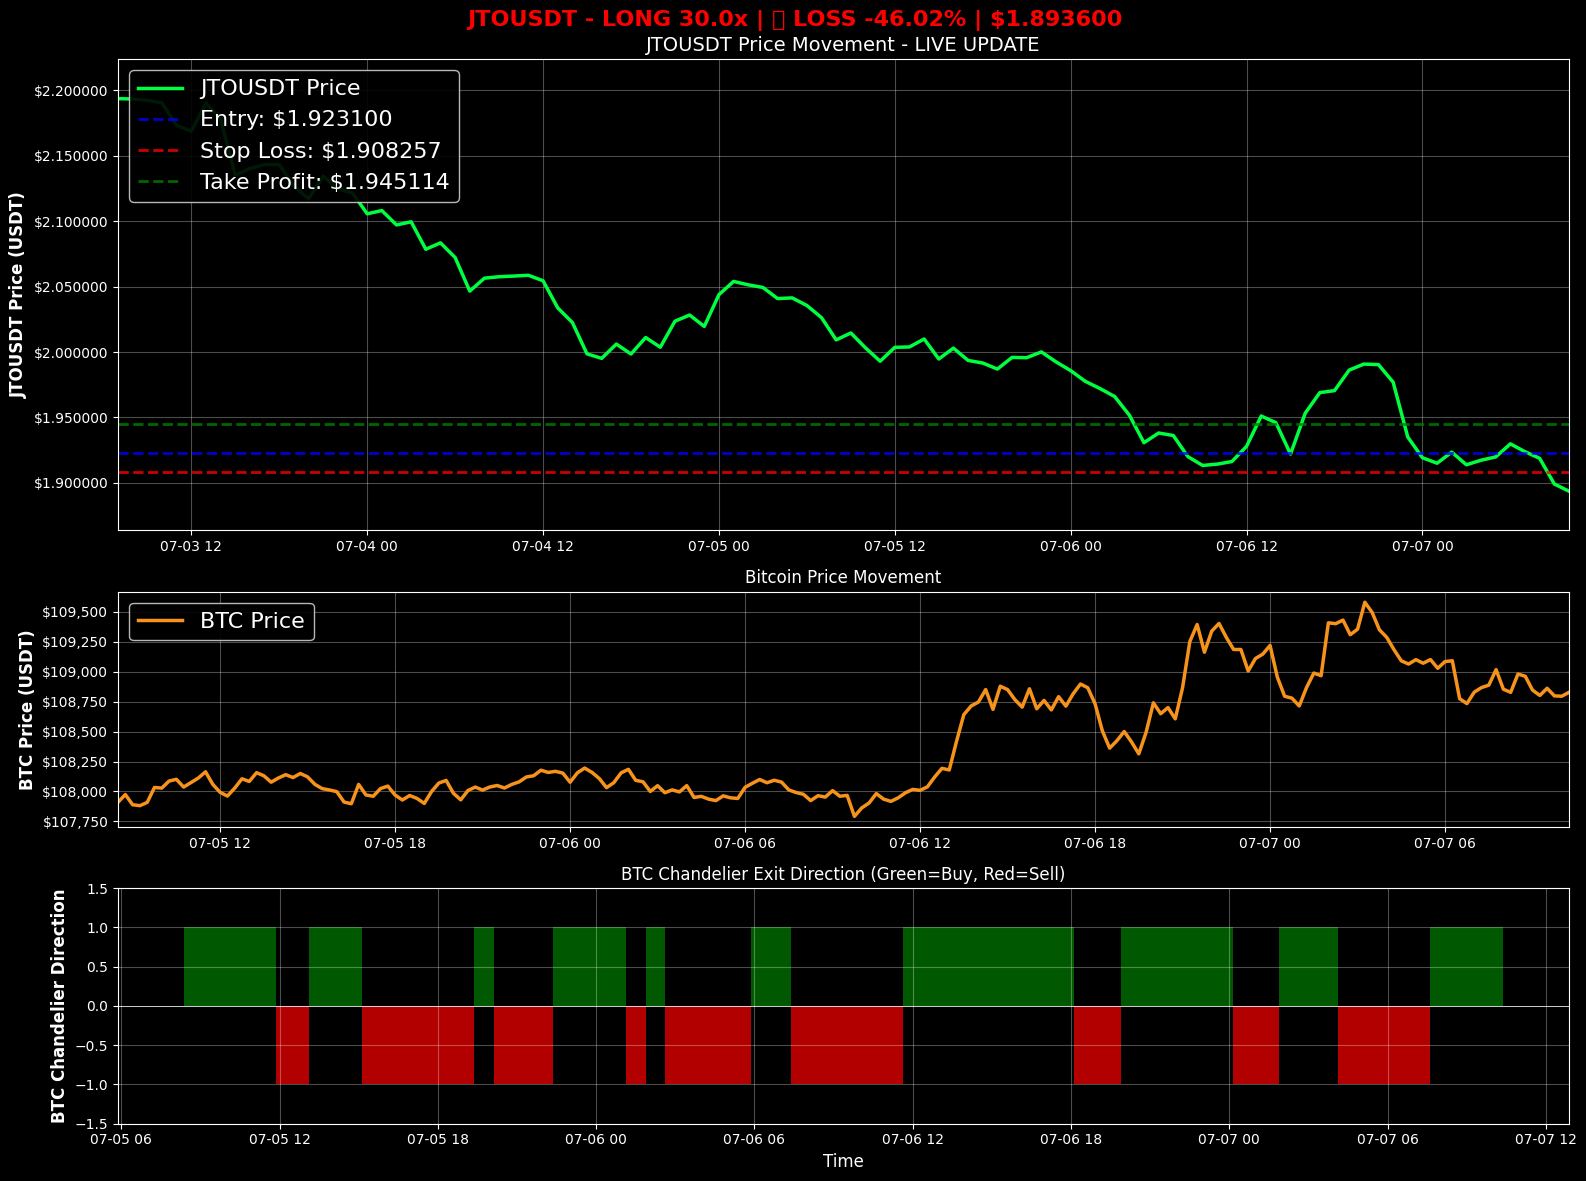

In [3]:
track_perpetual_trade_realtime(CSV_PATH, update_interval=10)

🚀 Starting real-time tracking for JTOUSDT
📊 Updates every 10.0 seconds
🎯 Close the plot window to stop tracking
📡 Performing initial data fetch...


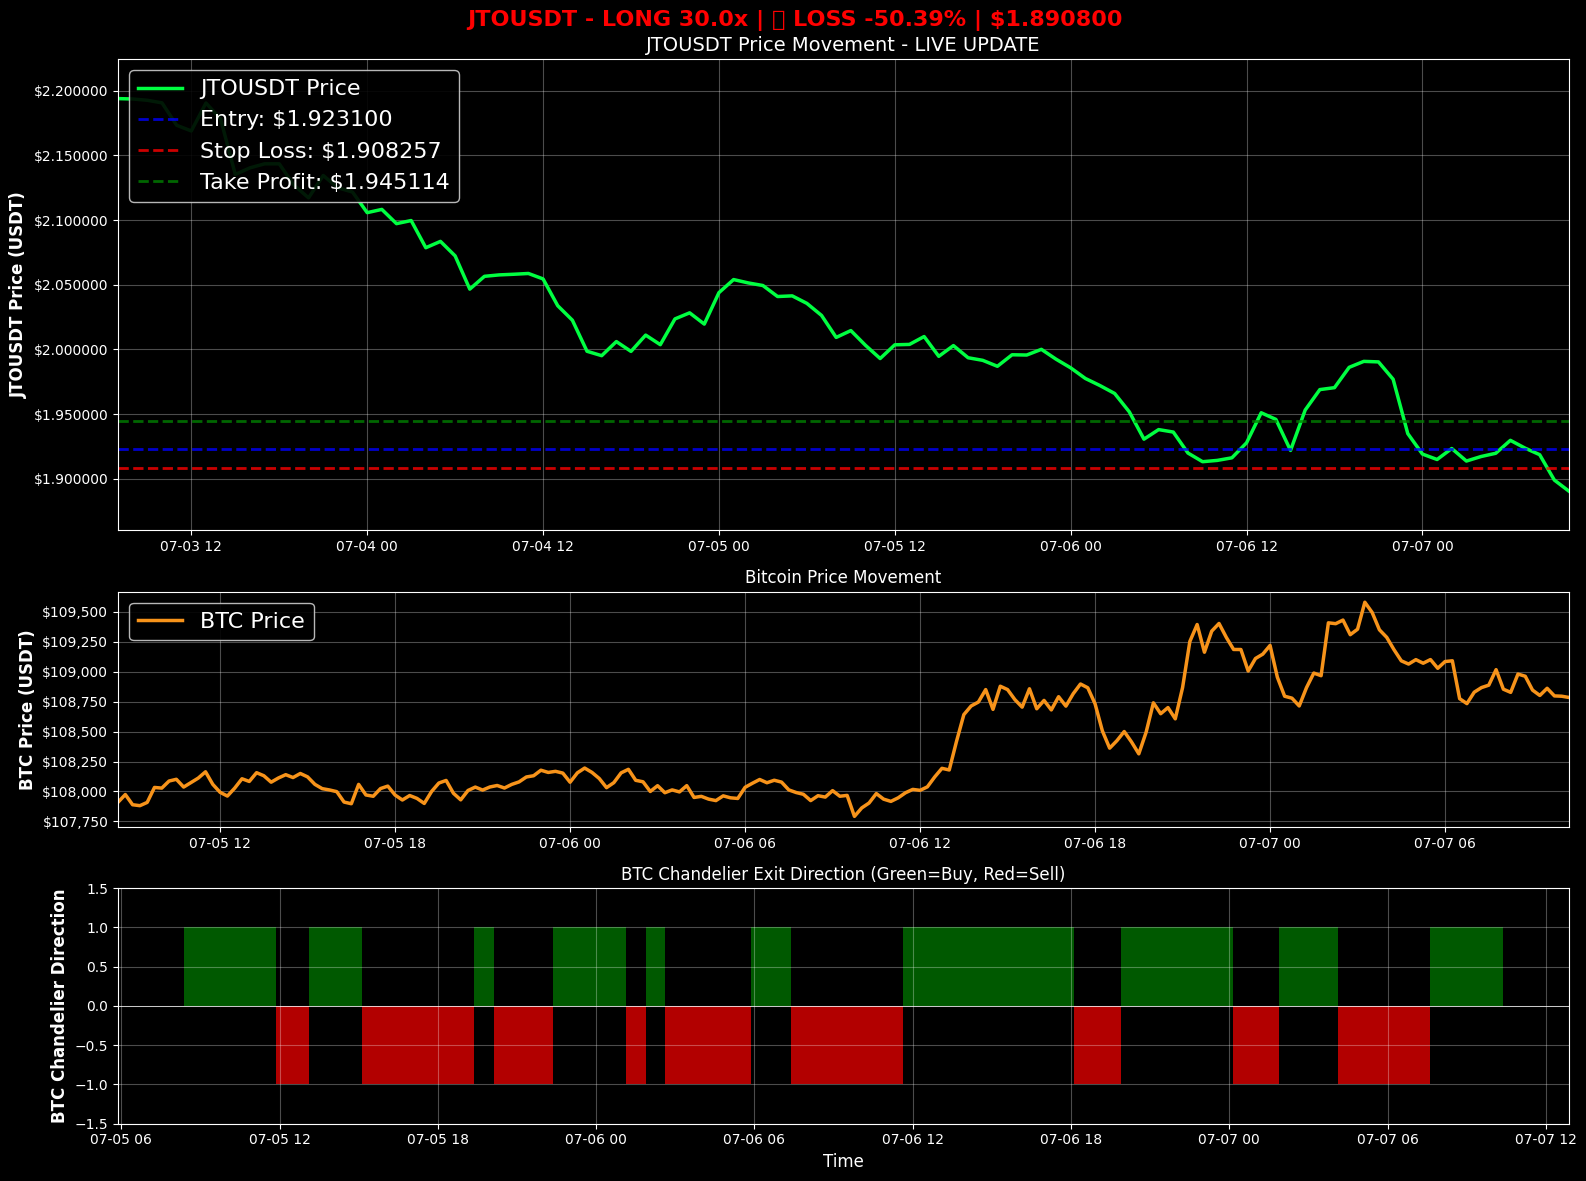

🚀 Starting real-time tracking for JTOUSDT
📊 Updates every 10.0 seconds
🎯 Close the plot window to stop tracking
📡 Performing initial data fetch...


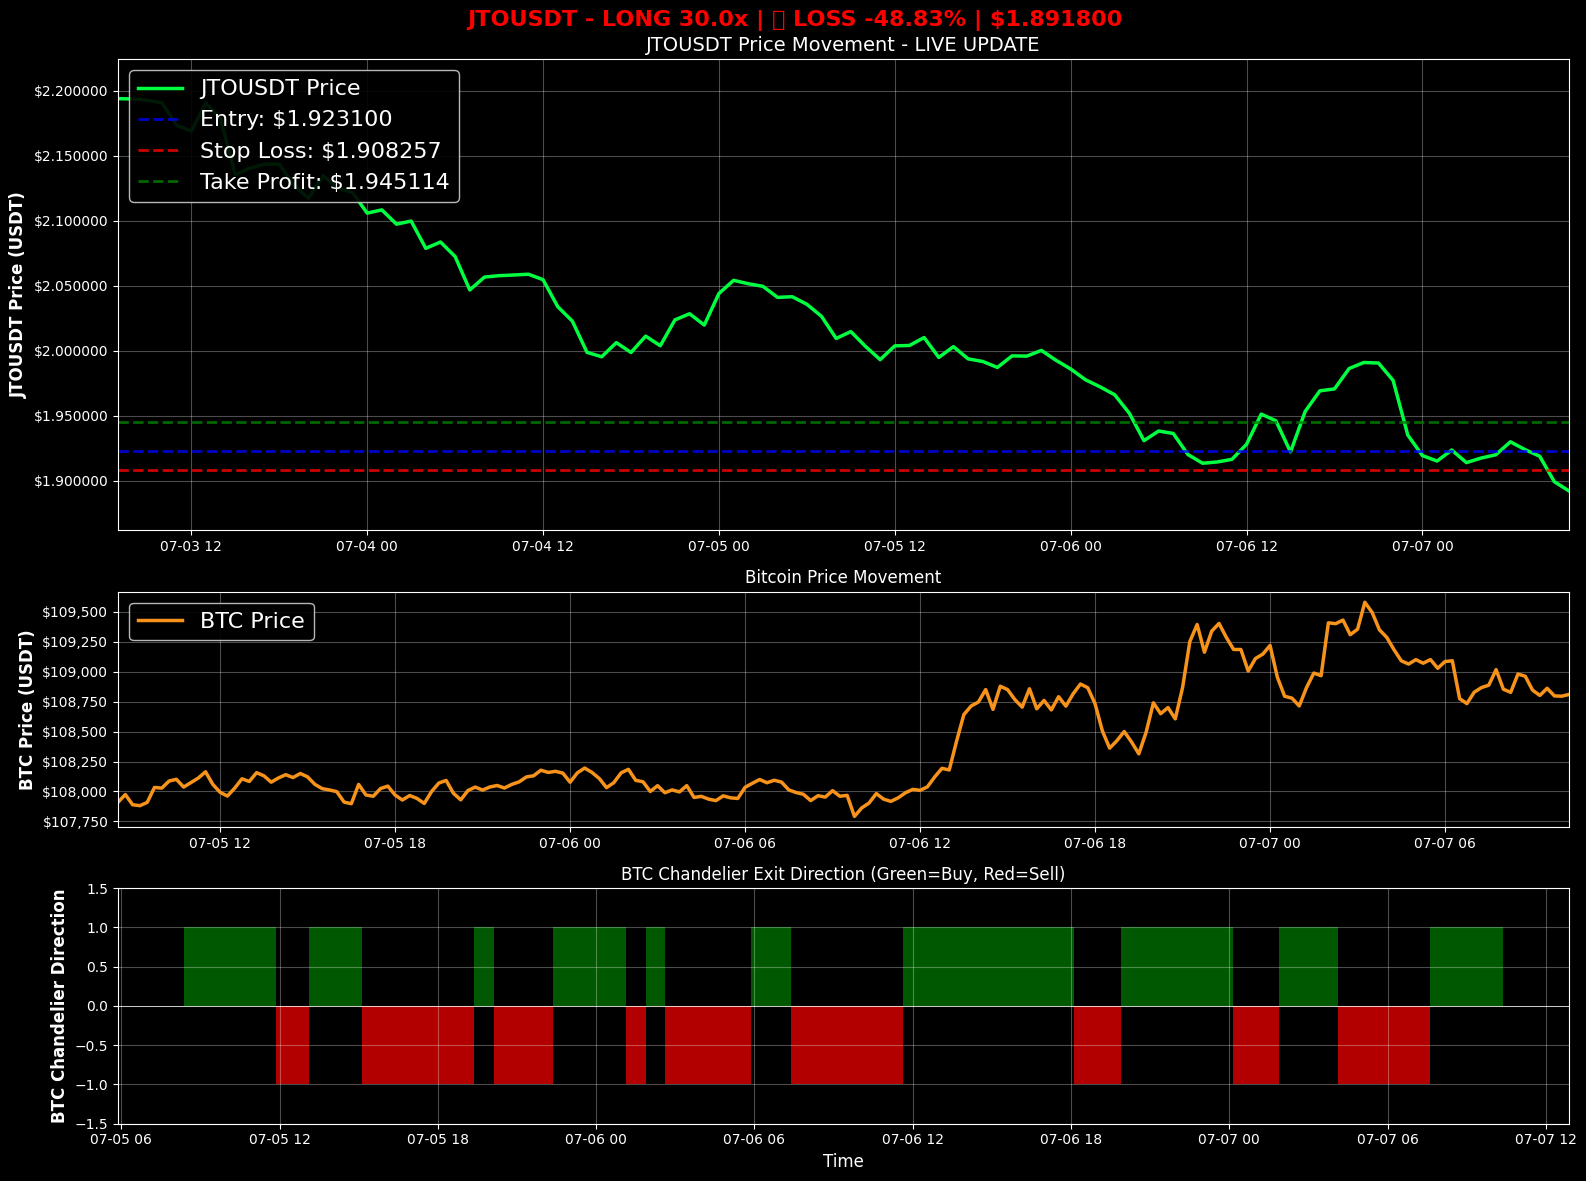

🚀 Starting real-time tracking for JTOUSDT
📊 Updates every 10.0 seconds
🎯 Close the plot window to stop tracking
📡 Performing initial data fetch...


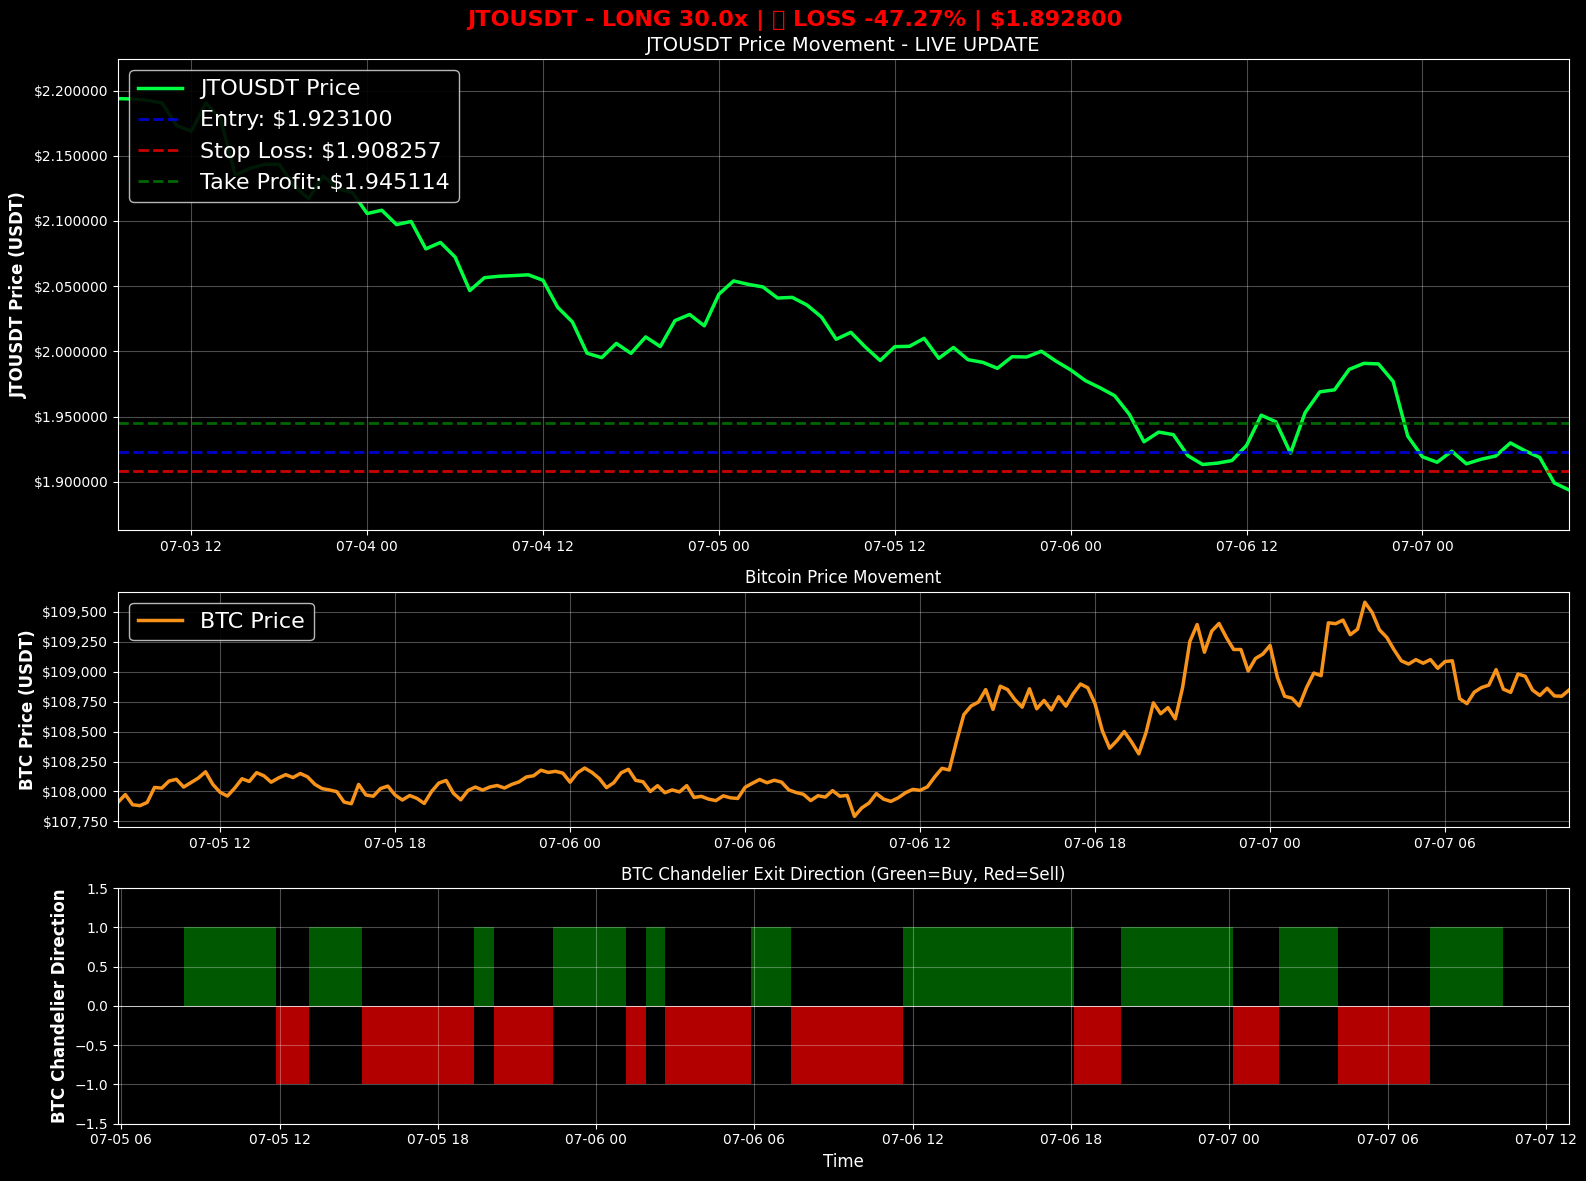

KeyboardInterrupt: 

In [5]:
import time
import matplotlib.pyplot as plt

def main():
    while True:
        # close any existing figures
        plt.close('all')

        # fetch & plot your latest data
        track_perpetual_trade_realtime(CSV_PATH, update_interval=10)

        # pause briefly to allow the plot to render
        plt.pause(0.1)

        # then wait before the next update
        time.sleep(10)

if __name__ == "__main__":
    # turn on interactive mode so plt.pause() works
    plt.ion()
    main()